In [305]:
# imports


import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [306]:
data = pd.read_csv('Datasets/smartwatches.csv')

data.drop_duplicates(inplace=True)

# train_df = data.sample(frac=0.8, random_state=42)
# test_df = data.drop(train_df.index)

# train_df = train_df.reset_index()
# test_df = test_df.reset_index()

In [307]:
train_df = data.copy()

In [308]:
data.shape, train_df.shape

((450, 16), (450, 16))

In [309]:
train_df.head()

,Unnamed: 0,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,NaN,NaN,NaN,NaN,8.0,Yes,NaN,35 - 50 g
1,1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,50 - 75 g
2,2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,NaN,NaN,Silicon,Yes,8.0,Yes,1.7 inches,35 - 50 g
3,3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,75g +
4,4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,NaN,NaN,Other,Yes,8.0,Yes,1.7 inches,35 - 50 g


In [310]:
train_df.drop(['Unnamed: 0'], axis=1, inplace=True)
train_df.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,NaN,NaN,NaN,NaN,8.0,Yes,NaN,35 - 50 g
1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,50 - 75 g
2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,NaN,NaN,Silicon,Yes,8.0,Yes,1.7 inches,35 - 50 g
3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,75g +
4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,NaN,NaN,Other,Yes,8.0,Yes,1.7 inches,35 - 50 g


In [311]:
train_df['Display Size'].isna().sum()

np.int64(30)

In [312]:
train_df['Display Size'].value_counts().count()

np.int64(40)

In [313]:
train_df['Display Size'].fillna('0.0 inches', inplace=True)
train_df['Display Size'].isna().sum()

C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2060797571.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Display Size'].fillna('0.0 inches', inplace=True)


np.int64(0)

In [314]:
train_df['Display Size'] = train_df['Display Size'].apply(lambda x: float(x.split()[0]))

# float('0.0 inches'.split()[0])

In [315]:
train_df['Display Size'].replace(0.0, np.nan, inplace=True)

train_df['Display Size'].isna().sum()

C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2734313038.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Display Size'].replace(0.0, np.nan, inplace=True)


np.int64(31)

In [316]:
train_df['Weight'].value_counts()

Weight
20 - 35 g    80
75g +        66
35 - 50 g    58
<= 20 g      43
50 - 75 g    17
Name: count, dtype: int64

In [317]:
re.findall('\d+', '20 - 35 g')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\3142025644.py:1: SyntaxWarning: invalid escape sequence '\d'
  re.findall('\d+', '20 - 35 g')


['20', '35']

In [318]:
cal = sum([int(x) for x in re.findall('\d+', '20 - 35 g')]) / 2

train_df['Weight'].replace('20 - 35 g', cal, inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2181387236.py:1: SyntaxWarning: invalid escape sequence '\d'
  cal = sum([int(x) for x in re.findall('\d+', '20 - 35 g')]) / 2
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2181387236.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('20 - 35 g', cal, inplace=True)


In [319]:
cal = sum([int(x) for x in re.findall('\d+', '35 - 50 g')]) / 2

train_df['Weight'].replace('35 - 50 g', cal, inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\4170158647.py:1: SyntaxWarning: invalid escape sequence '\d'
  cal = sum([int(x) for x in re.findall('\d+', '35 - 50 g')]) / 2
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\4170158647.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('35 - 50 g', cal, inplace=True)


In [320]:
cal = sum([int(x) for x in re.findall('\d+', '50 - 75 g')]) / 2

train_df['Weight'].replace('50 - 75 g', cal, inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2723606332.py:1: SyntaxWarning: invalid escape sequence '\d'
  cal = sum([int(x) for x in re.findall('\d+', '50 - 75 g')]) / 2
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2723606332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('50 - 75 g', cal, inplace=True)


In [321]:
train_df['Weight'].replace('75g +', float(re.findall('\d+', '75g +')[0]), inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\3271034506.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_df['Weight'].replace('75g +', float(re.findall('\d+', '75g +')[0]), inplace=True)
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\3271034506.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('75g +', float(re.findall('\d+', '75g +')[0]), inplace=True)


In [322]:
train_df['Weight'].replace('<= 20 g', float(re.findall('\d+', '<= 20 g')[0]), inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\1289372860.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_df['Weight'].replace('<= 20 g', float(re.findall('\d+', '<= 20 g')[0]), inplace=True)
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\1289372860.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('<= 20 g', float(re.findall('\d+', '<= 20 g')[0]), inplace=True)
C:\Users\bhave\AppData

In [323]:
train_df['Weight'].value_counts()

Weight
27.5    80
75.0    66
42.5    58
20.0    43
62.5    17
Name: count, dtype: int64

In [324]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                450 non-null    object 
 1   Current Price        440 non-null    float64
 2   Original Price       377 non-null    float64
 3   Discount Percentage  377 non-null    float64
 4   Rating               444 non-null    float64
 5   Number OF Ratings    391 non-null    float64
 6   Model Name           415 non-null    object 
 7   Dial Shape           327 non-null    object 
 8   Strap Color          327 non-null    object 
 9   Strap Material       381 non-null    object 
 10  Touchscreen          413 non-null    object 
 11  Battery Life (Days)  418 non-null    float64
 12  Bluetooth            444 non-null    object 
 13  Display Size         419 non-null    float64
 14  Weight               264 non-null    float64
dtypes: float64(8), object(7)
memory usage: 5

In [325]:
train_df['Discount Price'] = train_df['Original Price'] * (-train_df['Discount Percentage']) / 100

train_df.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Discount Price
0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,NaN,NaN,NaN,NaN,8.0,Yes,NaN,42.5,-6910.000000
1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,NaN,NaN,Silicon,Yes,3.5,Yes,1.8,62.5,-13200.000001
2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,NaN,NaN,Silicon,Yes,8.0,Yes,1.7,42.5,-5991.000000
3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,NaN,NaN,Silicon,Yes,3.5,Yes,1.8,75.0,-18200.000000
4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,NaN,NaN,Other,Yes,8.0,Yes,1.7,42.5,-3400.000000


In [326]:
train_df.drop(['Discount Percentage'], axis=1, inplace=True)

#### Numerical Data

In [327]:
numerical_col = [feature for feature in train_df.columns if train_df[feature].dtype == 'float64']
numerical_col

['Current Price',
 'Original Price',
 'Rating',
 'Number OF Ratings',
 'Battery Life (Days)',
 'Display Size',
 'Weight',
 'Discount Price']

In [328]:
train_df[numerical_col].head()

,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Display Size,Weight,Discount Price
0,82990.0,89900.0,4.0,65.0,8.0,NaN,42.5,-6910.000000
1,3799.0,16999.0,4.3,20788.0,3.5,1.8,62.5,-13200.000001
2,1999.0,7990.0,3.8,21724.0,8.0,1.7,42.5,-5991.000000
3,1799.0,19999.0,4.3,13244.0,3.5,1.8,75.0,-18200.000000
4,1599.0,4999.0,4.1,13901.0,8.0,1.7,42.5,-3400.000000


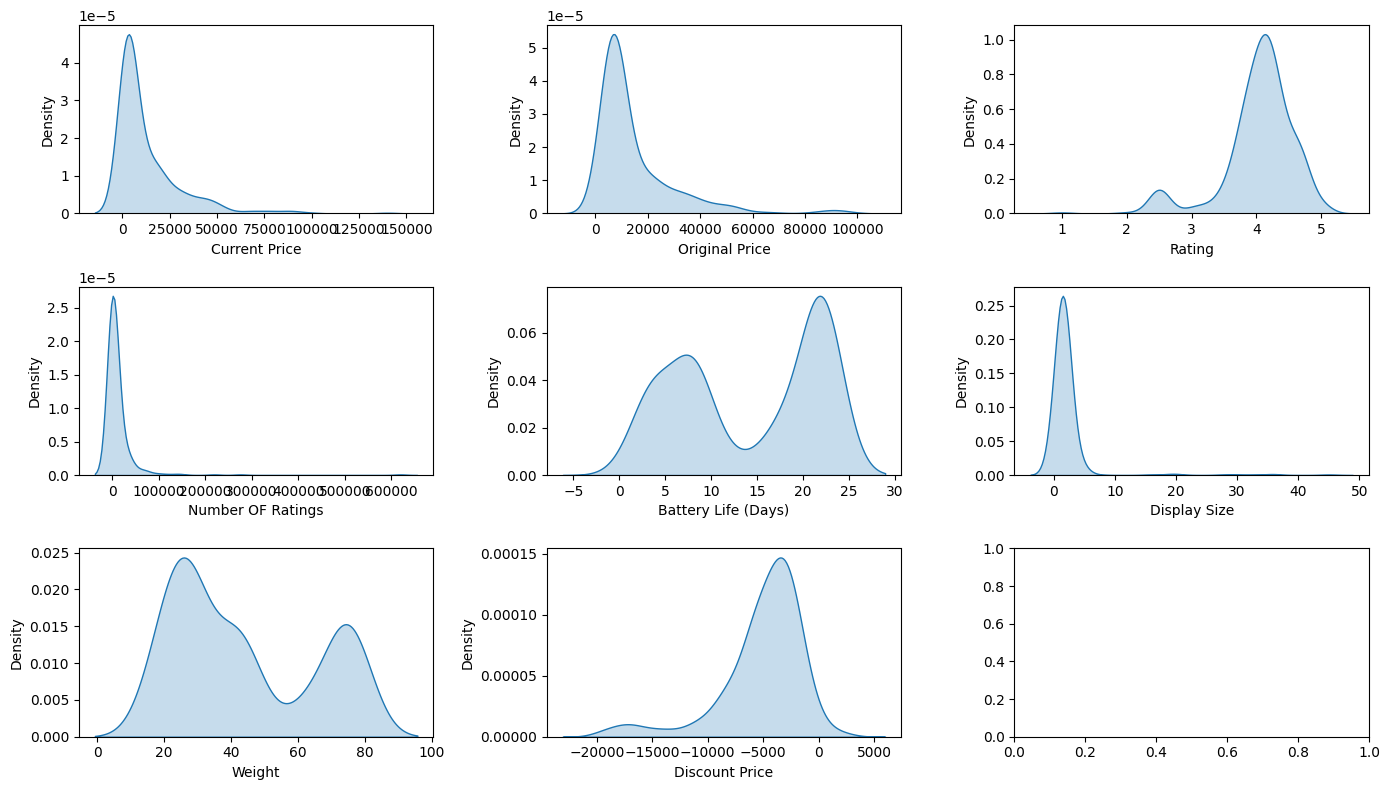

In [329]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 8))

for i, column in enumerate(numerical_col):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.kdeplot(data=train_df[column], ax=ax, fill=True)

fig.tight_layout()
plt.show()

# Skewness replace nan with median 

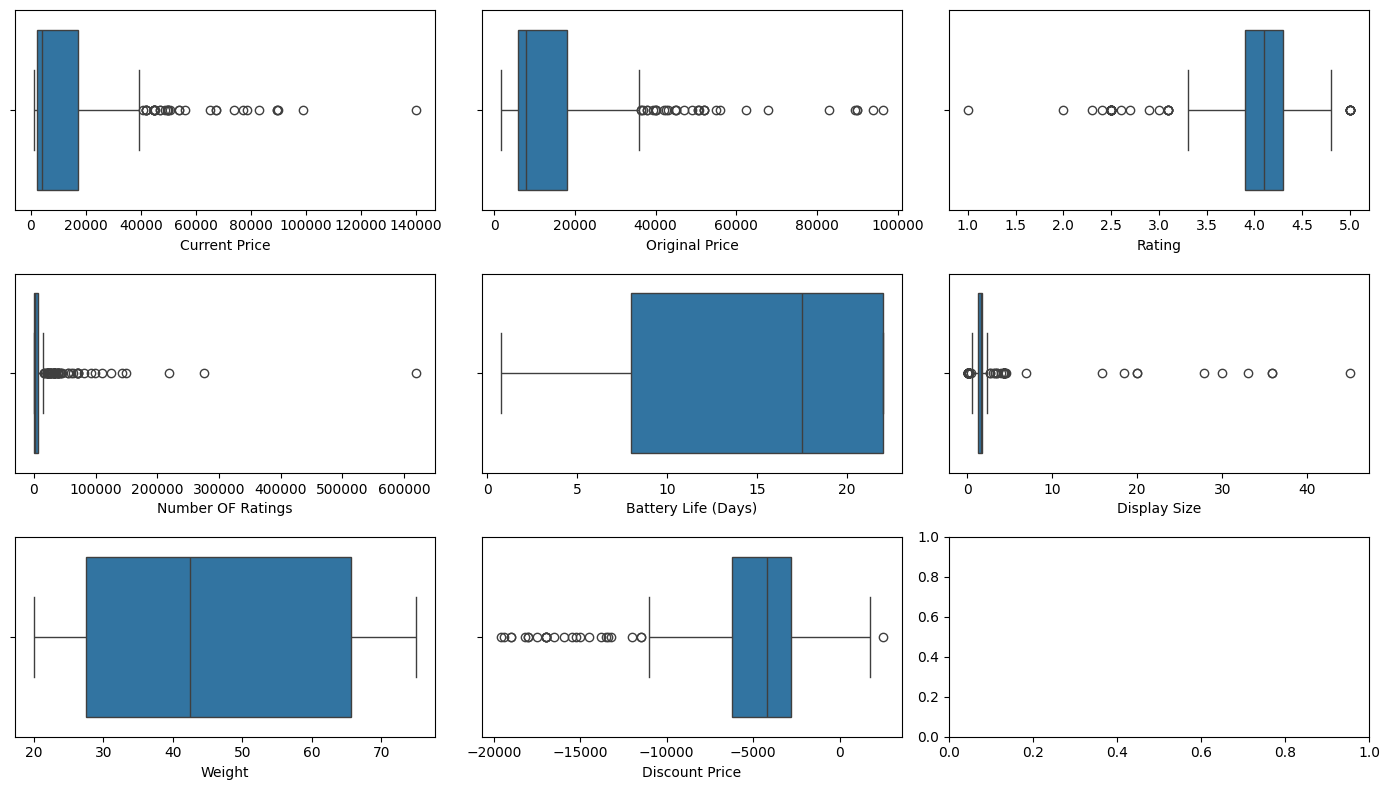

In [330]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 8))

for i, column in enumerate(numerical_col):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(x=train_df[column], ax=ax)

fig.tight_layout()
plt.show()

In [331]:
train_df.columns
train_df.shape

(450, 15)

In [332]:
# Remove Outlier

def remove_outliers_IQR (data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[col] > lower_bound) & (data[col] < upper_bound)]

# col having outliers
important_col = ['Current Price', 'Original Price', 'Rating', 'Number OF Ratings', 'Display Size']

for col in important_col:
    train_df = remove_outliers_IQR(train_df, col)

In [333]:
train_df.head()

,Brand,Current Price,Original Price,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Discount Price
1,fire-boltt,3799.0,16999.0,4.3,20788.0,BSW046,NaN,NaN,Silicon,Yes,3.5,Yes,1.8,62.5,-13200.000001
2,boat,1999.0,7990.0,3.8,21724.0,Wave Call,NaN,NaN,Silicon,Yes,8.0,Yes,1.7,42.5,-5991.000000
3,fire-boltt,1799.0,19999.0,4.3,13244.0,BSW053,NaN,NaN,Silicon,Yes,3.5,Yes,1.8,75.0,-18200.000000
4,noise,1599.0,4999.0,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,NaN,NaN,Other,Yes,8.0,Yes,1.7,42.5,-3400.000000
5,noise,1499.0,3999.0,4.0,32704.0,NSW-05,NaN,NaN,Other,Yes,8.0,Yes,1.7,42.5,-2500.000000


In [334]:
# Imputing the null values

import numpy as np
import pandas as pd
import re

# 1. Clean 'Display Size' to numeric (e.g. "1.4 inches" -> 1.4)
def clean_display_size(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'[\d.]+', str(val))
    return float(match.group()) if match else np.nan

train_df['Display Size (Inches)'] = train_df['Display Size'].apply(clean_display_size)

# 2. Clean 'Weight' to numeric
def clean_weight(val):
    if pd.isna(val):
        return np.nan
    nums = [float(x) for x in re.findall(r'\d+', str(val))]
    if len(nums) == 2:      # '20 - 35 g' -> midpoint (27.5)
        return sum(nums) / 2
    elif len(nums) == 1:    # '75g +' or '<= 20 g' -> 75.0 or 20.0
        return nums[0]
    return np.nan

train_df['Weight (g)'] = train_df['Weight'].apply(clean_weight)

# Drop redundant old raw columns
train_df.drop(columns=['Weight', 'Display Size'], inplace=True, errors='ignore')

# Impute Model Name (or drop it)
train_df['Model Name'] = train_df['Model Name'].fillna('Unknown')


# 3. Impute Numerical Features with Groupby (Brand Median) -> Global Fallback
numerical_to_impute = ['Display Size (Inches)', 'Weight (g)', 'Battery Life (Days)', 'Rating', 'Number OF Ratings']

for col in numerical_to_impute:
    # Calculate median per brand
    brand_median = train_df.groupby('Brand')[col].transform('median')
    # Fill with brand median first, then global median if still NaN
    train_df[col] = train_df[col].fillna(brand_median).fillna(train_df[col].median())

# 4. Impute Categorical Features (Dial Shape, Strap Material, etc.)
# If missing rate is high (like Dial Shape ~27%), filling with 'Unknown' or Brand Mode is best:
categorical_to_impute = ['Dial Shape', 'Strap Material', 'Strap Color', 'Touchscreen', 'Bluetooth']

for col in categorical_to_impute:
    # Option A: Replace missing with 'Unknown' (avoids fabricating unknown specs)
    train_df[col] = train_df[col].fillna('Unknown')


In [335]:
train_df.isna().sum()

Brand                    0
Current Price            0
Original Price           0
Rating                   0
Number OF Ratings        0
Model Name               0
Dial Shape               0
Strap Color              0
Strap Material           0
Touchscreen              0
Battery Life (Days)      0
Bluetooth                0
Discount Price           0
Display Size (Inches)    0
Weight (g)               0
dtype: int64

In [336]:
numerical_col

['Current Price',
 'Original Price',
 'Rating',
 'Number OF Ratings',
 'Battery Life (Days)',
 'Display Size',
 'Weight',
 'Discount Price']

In [337]:
# train_df[numerical_col]

# Re-fetch the numerical columns from the updated dataframe
numerical_col = train_df.select_dtypes(include=['float64', 'int64', 'number']).columns.tolist()

# Now view the numerical columns
train_df[numerical_col].head()


,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Discount Price,Display Size (Inches),Weight (g)
1,3799.0,16999.0,4.3,20788.0,3.5,-13200.000001,1.8,33.5
2,1999.0,7990.0,3.8,21724.0,8.0,-5991.000000,1.7,23.5
3,1799.0,19999.0,4.3,13244.0,3.5,-18200.000000,1.8,37.5
4,1599.0,4999.0,4.1,13901.0,8.0,-3400.000000,1.7,23.5
5,1499.0,3999.0,4.0,32704.0,8.0,-2500.000000,1.7,23.5


In [338]:
train_df.shape

(181, 15)

#### Feature Engineering

In [339]:
# Feature Engineering

from sklearn.preprocessing import MinMaxScaler

In [340]:
# 1. Define the exact numerical features to scale
features_to_scale = [
    'Current Price', 
    'Original Price', 
    'Rating', 
    'Number OF Ratings', 
    'Battery Life (Days)', 
    'Display Size (Inches)', 
    'Weight (g)'
]

# 2. Scale and assign directly back to train_df (preserves indices & prevents NaN shifting)
scaler = MinMaxScaler()
train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])

# 3. Check the result
train_df[features_to_scale].head()


,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Display Size (Inches),Weight (g)
1,0.111631,0.568365,0.833333,0.622082,0.129412,0.615385,0.854545
2,0.034348,0.229960,0.416667,0.650096,0.341176,0.538462,0.490909
3,0.025761,0.681053,0.833333,0.396295,0.129412,0.615385,1.000000
4,0.017174,0.117609,0.666667,0.415958,0.341176,0.538462,0.490909
5,0.012881,0.080047,0.583333,0.978720,0.341176,0.538462,0.490909


In [341]:
train_df.isna().sum()

Brand                    0
Current Price            0
Original Price           0
Rating                   0
Number OF Ratings        0
Model Name               0
Dial Shape               0
Strap Color              0
Strap Material           0
Touchscreen              0
Battery Life (Days)      0
Bluetooth                0
Discount Price           0
Display Size (Inches)    0
Weight (g)               0
dtype: int64

In [342]:
train_df.head()

,Brand,Current Price,Original Price,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Discount Price,Display Size (Inches),Weight (g)
1,fire-boltt,0.111631,0.568365,0.833333,0.622082,BSW046,Unknown,Unknown,Silicon,Yes,0.129412,Yes,-13200.000001,0.615385,0.854545
2,boat,0.034348,0.229960,0.416667,0.650096,Wave Call,Unknown,Unknown,Silicon,Yes,0.341176,Yes,-5991.000000,0.538462,0.490909
3,fire-boltt,0.025761,0.681053,0.833333,0.396295,BSW053,Unknown,Unknown,Silicon,Yes,0.129412,Yes,-18200.000000,0.615385,1.000000
4,noise,0.017174,0.117609,0.666667,0.415958,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,Unknown,Unknown,Other,Yes,0.341176,Yes,-3400.000000,0.538462,0.490909
5,noise,0.012881,0.080047,0.583333,0.978720,NSW-05,Unknown,Unknown,Other,Yes,0.341176,Yes,-2500.000000,0.538462,0.490909


#### Categorical Columns

In [343]:
categorical_col = train_df.select_dtypes(include=['object']).columns.tolist()
categorical_col.remove('Bluetooth')

In [344]:
from scipy.stats import f_oneway

for col in categorical_col:
    CategoryGroupLists = train_df.groupby(col)['Discount Price'].apply(list)
    AnovaResults = f_oneway(*CategoryGroupLists)
    print(col, ": ", 'P-Value for anova is : ', AnovaResults[1])

Brand :  P-Value for anova is :  8.421850586222163e-14
Model Name :  P-Value for anova is :  6.409890487103267e-08
Dial Shape :  P-Value for anova is :  0.0010576944188830347
Strap Color :  P-Value for anova is :  0.19844320142105273
Strap Material :  P-Value for anova is :  0.0013723632820284313
Touchscreen :  P-Value for anova is :  0.31095053466889433


In [351]:
# ✅ CORRECT: Use exact string names in quotes
imp_col = ['Brand', 'Model Name', 'Dial Shape', 'Strap Material']

# Select columns from train_df
train_df[imp_col].head()


,Brand,Model Name,Dial Shape,Strap Material
1,fire-boltt,BSW046,Unknown,Silicon
2,boat,Wave Call,Unknown,Silicon
3,fire-boltt,BSW053,Unknown,Silicon
4,noise,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,Unknown,Other
5,noise,NSW-05,Unknown,Other


In [346]:
train_df[imp_col].isna().sum()

Brand             0
Model Name        0
Dial Shape        0
Strap Material    0
dtype: int64

In [347]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Brand', 'Model Name', 'Dial Shape', 'Strap Material', 'Touchscreen', 'Bluetooth']

# 1. Initialize encoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# 2. Fit on train data
encoded_train = encoder.fit_transform(train_df[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_train, 
    columns=encoder.get_feature_names_out(categorical_cols), 
    index=train_df.index
)

# 3. Concatenate with numerical features and drop original categorical columns
train_df_encoded = pd.concat([train_df.drop(columns=categorical_cols), encoded_df], axis=1)


In [348]:
train_df_encoded.head()

,Current Price,Original Price,Rating,Number OF Ratings,Strap Color,Battery Life (Days),Discount Price,Display Size (Inches),Weight (g),Brand_ambrane,...,Strap Material_Other,Strap Material_Plastic,Strap Material_Rubber,Strap Material_Silicon,Strap Material_Stainless Steel,Strap Material_Synthetic,Strap Material_Thermo Plastic Polyurethene,Strap Material_Unknown,Touchscreen_Unknown,Touchscreen_Yes
1,0.111631,0.568365,0.833333,0.622082,Unknown,0.129412,-13200.000001,0.615385,0.854545,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.034348,0.229960,0.416667,0.650096,Unknown,0.341176,-5991.000000,0.538462,0.490909,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.025761,0.681053,0.833333,0.396295,Unknown,0.129412,-18200.000000,0.615385,1.000000,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.017174,0.117609,0.666667,0.415958,Unknown,0.341176,-3400.000000,0.538462,0.490909,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.012881,0.080047,0.583333,0.978720,Unknown,0.341176,-2500.000000,0.538462,0.490909,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [350]:
train_df_encoded.to_csv('./Datasets/cleaned.csv', index=False)

>Next Step Recommendation for Modeling: Notice that cleaned.csv has 204 columns for only 181 rows (shape: (181, 204)).

This happened because OneHotEncoder encoded Model Name, which created ~180 sparse columns (almost one per watch). For better ML performance and to prevent overfitting:

Drop Model Name before One-Hot Encoding, or keep only general features ('Brand', 'Dial Shape', 'Strap Material', 'Touchscreen', 'Bluetooth').
This will keep your feature count around ~25–30 clean, dense columns.